# 01 · PJM Energy Demand — Advanced EDA I: Distributions & Calendar

## Part 1 — Advanced EDA I: Distributions & Calendar Structure

A thorough cross-section of *what demand looks like* and *how the calendar shapes it*: the
distribution and its moments, the **triple seasonality** (daily × weekly × annual), the way the daily
shape **changes with season**, the weekend and holiday effects, the utility's **load-duration curve**,
and the surprising long-run trend.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

d = data.clean_primary(); s = d.load_mw
print("hours:", len(s), "| span:", s.index.min().date(), "->", s.index.max().date())

setup ok | numpy 2.1.3 | pandas 2.3.3


hours: 145392 | span: 2002-01-01 -> 2018-08-03


### 1. The demand distribution

Load is strictly positive and **mildly right-skewed** (skew ≈ 0.74): most hours sit near the ~32 GW
median, with a thinner tail of extreme high-demand hours (heat-wave afternoons). The four-view battery
shows the shape, spread, percentiles and departure from normality at once.

n                  145392.00
mean                32078.93
std                  6464.29
skew                    0.74
excess_kurtosis         0.74
min                 14544.00
median              31420.00
max                 62009.00


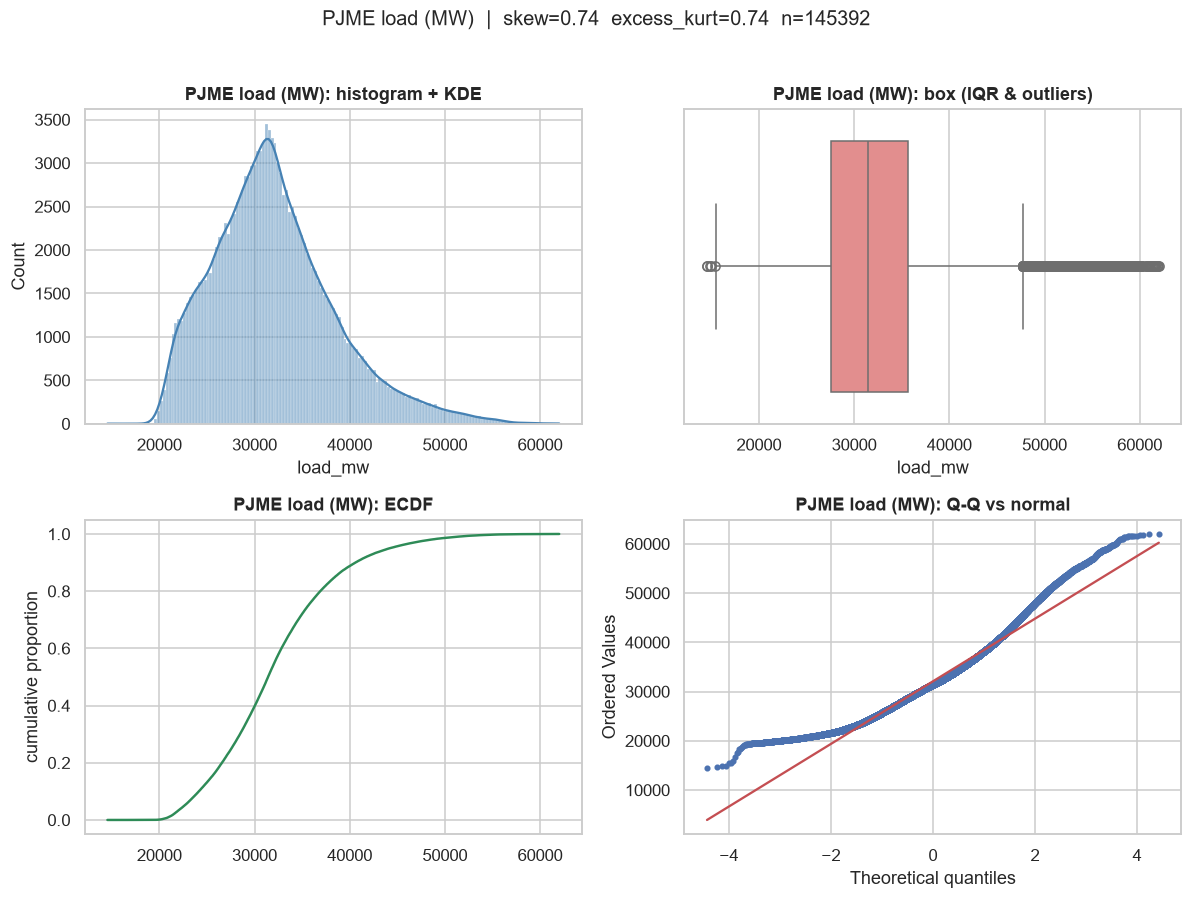

In [2]:
eda.four_view(s, "PJME load (MW)", "p1_dist.png")
print(eda.moments(s).round(2).to_string())

### 2. The triple seasonality

Three calendar rhythms stacked on top of each other:
- **Daily** — trough around 04:00, rising to an evening peak.
- **Weekly** — weekdays higher than weekends (commerce & industry).
- **Annual** — **bimodal**: high in summer (A/C) *and* winter (heating), low in spring/autumn.

The annual bimodality is the signature of this dataset — most seasonal series have a single peak.

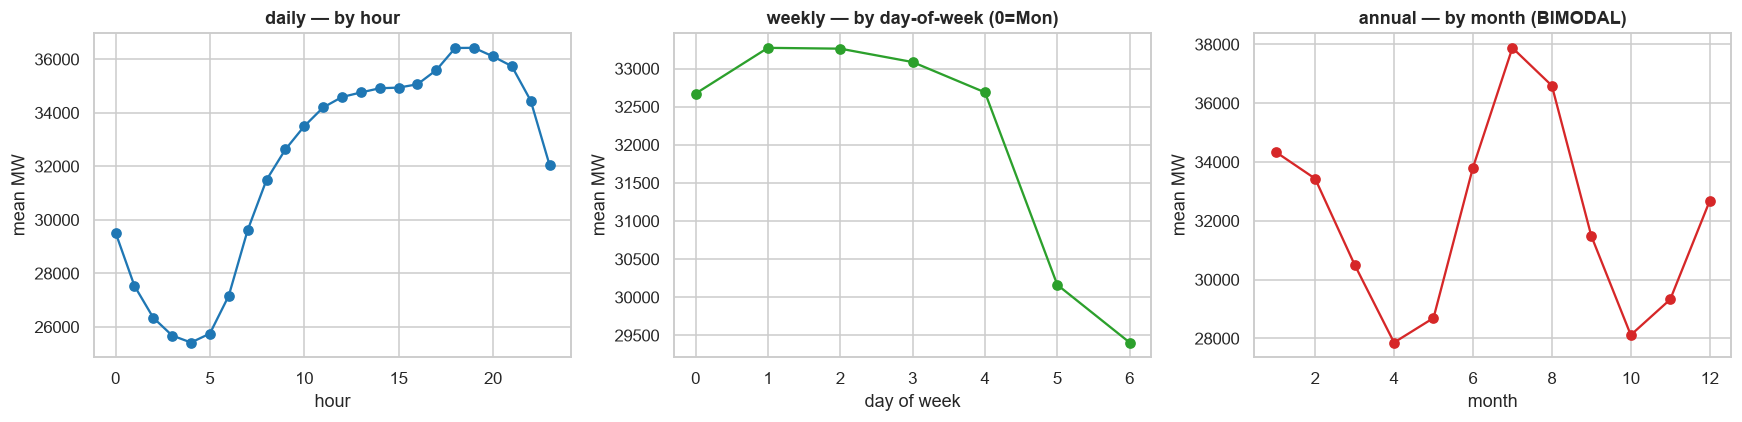

season means: {'fall': 29626.0, 'spring': 29035.0, 'summer': 36112.0, 'winter': 33503.0}


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
s.groupby(d.hour).mean().plot(ax=ax[0], marker="o", color="tab:blue"); ax[0].set_title("daily — by hour"); ax[0].set_xlabel("hour")
s.groupby(d.dow).mean().plot(ax=ax[1], marker="o", color="tab:green"); ax[1].set_title("weekly — by day-of-week (0=Mon)"); ax[1].set_xlabel("day of week")
s.groupby(d.month).mean().plot(ax=ax[2], marker="o", color="tab:red"); ax[2].set_title("annual — by month (BIMODAL)"); ax[2].set_xlabel("month")
for a in ax: a.set_ylabel("mean MW")
fig.tight_layout(); eda.savefig(fig, "p1_triple_season.png"); plt.show()
print("season means:", s.groupby(d.season).mean().round(0).to_dict())

### 3. Hour × day-of-week heatmap

Combining two cycles: weekdays show a strong daytime business peak; weekends are lower and flatter and
shift slightly later (no morning commute). This 2-D calendar fingerprint is what a good forecaster must
reproduce.

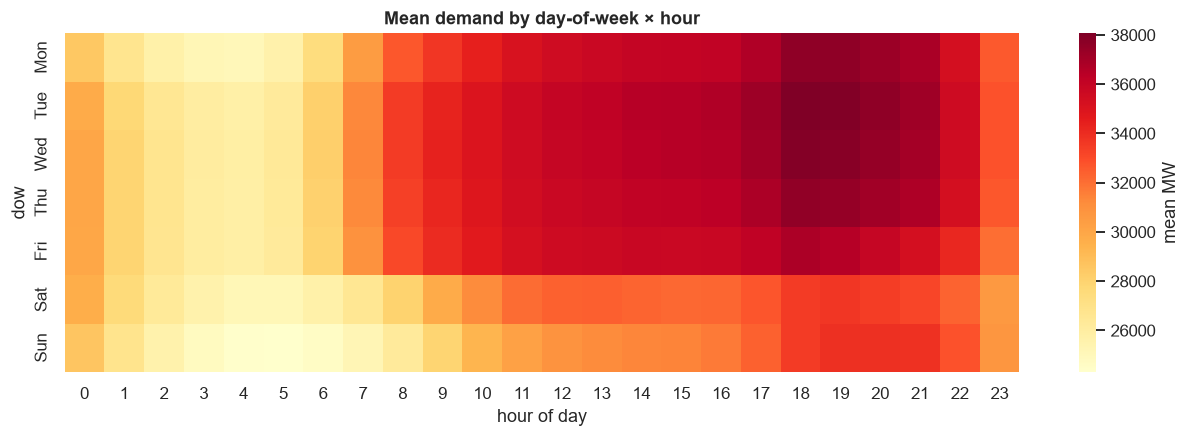

In [4]:
piv = s.groupby([d.dow, d.hour]).mean().unstack()
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(piv, cmap="YlOrRd", ax=ax, cbar_kws={"label": "mean MW"},
            yticklabels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_xlabel("hour of day"); ax.set_title("Mean demand by day-of-week × hour")
eda.savefig(fig, "p1_heatmap.png"); plt.show()

### 4. The daily shape *changes with season*

A subtlety pure averages hide: **summer and winter have different daily shapes**. Summer is a single
sharp **afternoon** peak (~17:00) as air-conditioning load tracks the day's heat. Winter is **double-
peaked** — a morning bump (people wake, heat homes) and a larger evening peak (return home + lights).
A model with one fixed daily profile will systematically miss this.

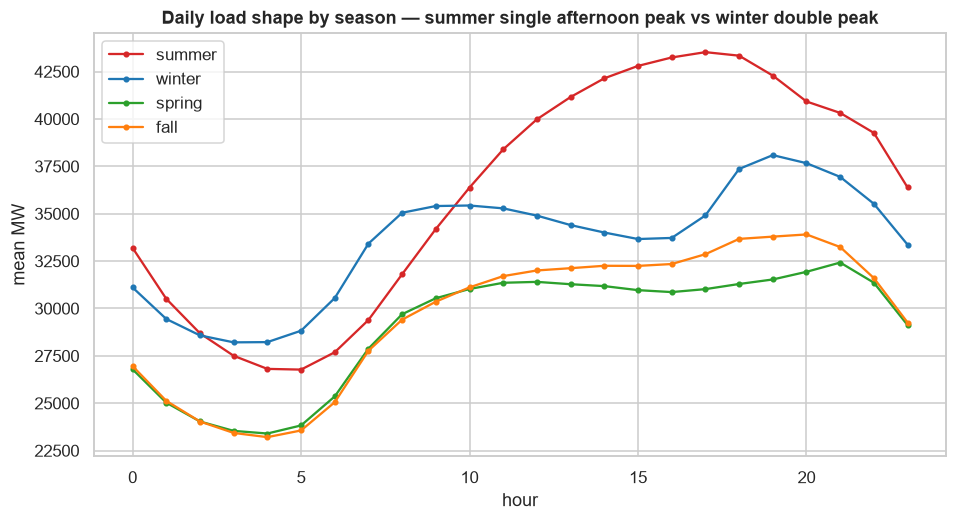

summer peak hour 17 | winter peak hours [19, 20]


In [5]:
prof = s.groupby([d.season, d.hour]).mean().unstack(0)
fig, ax = plt.subplots(figsize=(10, 5))
for seas, c in [("summer","tab:red"), ("winter","tab:blue"), ("spring","tab:green"), ("fall","tab:orange")]:
    ax.plot(prof.index, prof[seas], marker="o", ms=3, label=seas, color=c)
ax.set_xlabel("hour"); ax.set_ylabel("mean MW"); ax.set_title("Daily load shape by season — summer single afternoon peak vs winter double peak"); ax.legend()
eda.savefig(fig, "p1_seasonal_shape.png"); plt.show()
print("summer peak hour %d | winter peak hours %s" % (prof["summer"].idxmax(), list(prof["winter"].nlargest(2).index)))

### 5. Weekend & holiday effects

Demand falls **~10% on weekends** and **~6% on holidays** (vs working weekdays) — holidays behave like
an extra weekend dropped into the week. The Thanksgiving-week zoom shows the holiday carving a
weekend-shaped dip into a Thursday.

weekend reduction 9.7% | holiday reduction 6.4% (vs weekdays)


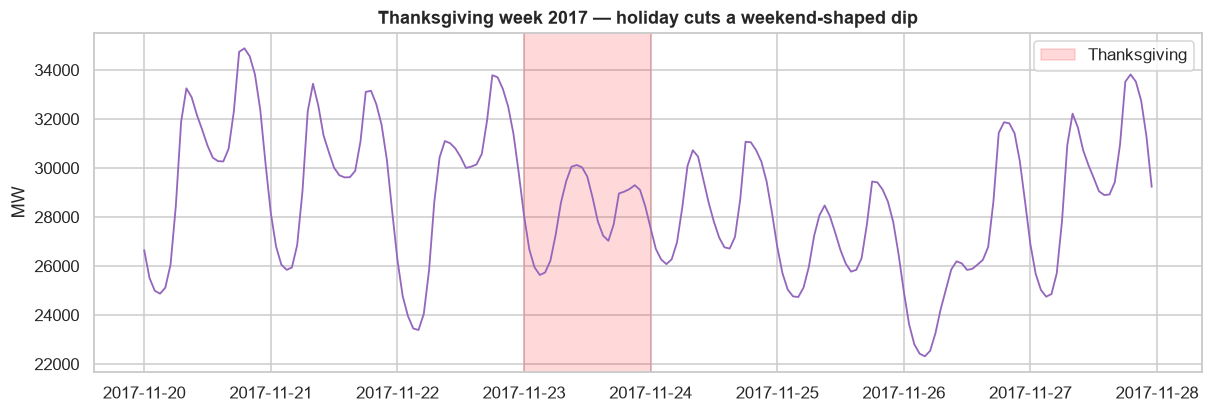

In [6]:
wk = 100*(1 - d[d.is_weekend==1].load_mw.mean()/d[d.is_weekend==0].load_mw.mean())
hol = 100*(1 - d[d.is_holiday==1].load_mw.mean()/d[(d.is_holiday==0)&(d.is_weekend==0)].load_mw.mean())
print("weekend reduction %.1f%% | holiday reduction %.1f%% (vs weekdays)" % (wk, hol))
zoom = s.loc["2017-11-20":"2017-11-27"]
fig, ax = plt.subplots(figsize=(13, 4)); ax.plot(zoom.index, zoom.values, color="tab:purple", lw=1.2)
ax.axvspan("2017-11-23", "2017-11-24", color="red", alpha=.15, label="Thanksgiving")
ax.set_ylabel("MW"); ax.set_title("Thanksgiving week 2017 — holiday cuts a weekend-shaped dip"); ax.legend()
eda.savefig(fig, "p1_holiday_zoom.png"); plt.show()

### 6. The load-duration curve

A staple of power-systems analysis: sort every hour's demand from highest to lowest. The steep left
edge is the few **peak hours** the grid must be built to serve; the long flat body is the everyday
base load. Here **peak demand is 4.3× the minimum** — most generating capacity exists for a handful of
extreme hours a year, the central economic problem of electricity systems.

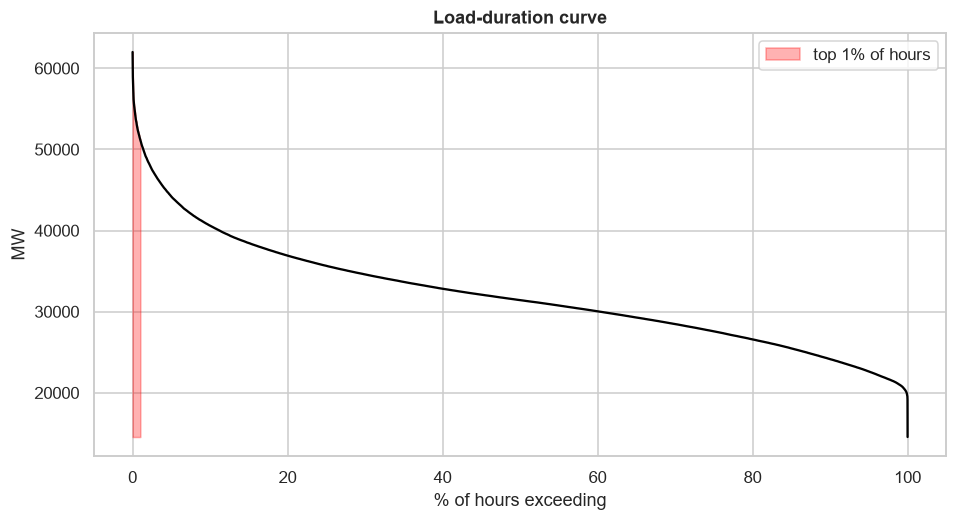

top-1% hours exceed 51159 MW | base (bottom 1%) below 20970 | peak/base ratio 4.26


In [7]:
sd = np.sort(s.values)[::-1]; pct = np.arange(len(sd))/len(sd)*100
fig, ax = plt.subplots(figsize=(10, 5)); ax.plot(pct, sd, color="black")
ax.fill_between(pct, sd, sd.min(), where=(pct<1), color="red", alpha=.3, label="top 1% of hours")
ax.set_xlabel("% of hours exceeding"); ax.set_ylabel("MW"); ax.set_title("Load-duration curve"); ax.legend()
eda.savefig(fig, "p1_load_duration.png"); plt.show()
print("top-1%% hours exceed %.0f MW | base (bottom 1%%) below %.0f | peak/base ratio %.2f" % (sd[int(.01*len(sd))], sd[int(.99*len(sd))], s.max()/s.min()))

### 7. The long-run trend — demand is *not* growing

Counterintuitively, annual-average demand **fell ~3% from 2003 to 2017** despite population and
economic growth. Efficiency (LED lighting, better appliances, building codes) and behind-the-meter
rooftop solar have outpaced demand growth — a real, much-discussed feature of mature US grids, and a
caution against assuming an upward trend.

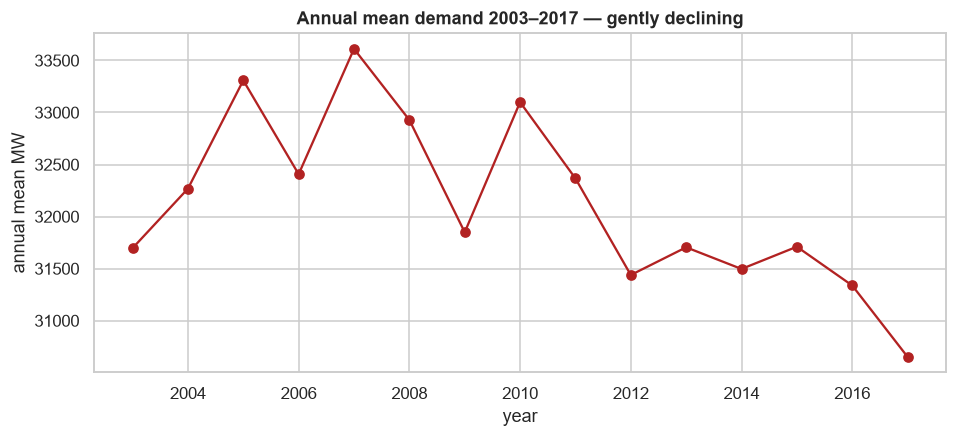

2003 31697 MW -> 2017 30652 MW (-3.3%)


In [8]:
ann = s[(d.year>=2003)&(d.year<=2017)].groupby(d.year).mean()
fig, ax = plt.subplots(figsize=(10, 4)); ann.plot(ax=ax, marker="o", color="firebrick")
ax.set_ylabel("annual mean MW"); ax.set_title("Annual mean demand 2003–2017 — gently declining")
eda.savefig(fig, "p1_yoy.png"); plt.show()
print("2003 %.0f MW -> 2017 %.0f MW (%.1f%%)" % (ann.loc[2003], ann.loc[2017], 100*(ann.loc[2017]/ann.loc[2003]-1)))

### Takeaways

- Demand is **mildly right-skewed** (skew 0.74) around a ~32 GW median, with a heat-wave tail.
- **Triple seasonality** (daily × weekly × annual) with a distinctive **bimodal** annual cycle
  (summer & winter peaks).
- The **daily shape changes with season** — summer single afternoon peak vs winter double peak — a
  trap for fixed-profile models.
- **Weekends −10%, holidays −6%**; the **load-duration curve** shows a peak/base ratio of **4.3**.
- The long-run trend is **flat-to-declining** (−3% over 2003–17) — efficiency beating growth.

**Next — Part 2 (Advanced EDA II):** the temporal deep-dive — ramp rates, intra-day volatility,
year-over-year shape changes, and the autocorrelation that makes load so forecastable.